# Framework Composite TrendWeather - Research

**Objectif:** Simuler les signaux alpha et la construction de portefeuille
pour iterer rapidement sur les parametres (allocations, risk management)
avant backtest cloud.

**Strategies combinees:**
- TrendStocks (50%): EMA20/50 + SMA200 sur 7 available tickers (Docker research)
- AllWeather (50%): Allocation statique SPY/TLT/GLD/XLF (30/30/30/10)

**Donnees:** yfinance (execution locale). Les prix peuvent differer legerement
de QC (ajustements), mais suffisant pour explorer les parametres.

## 0. Chargement des donnees

In [1]:
import pandas as pd
import numpy as np

qb = QuantBook()

# Docker-research available tickers: AAPL, MSFT, GOOGL, SPY, TLT, GLD, XLF, XLE
trend_tickers = ["AAPL", "QQQ", "GOOGL", "SPY", "USO", "BAC"]
aw_tickers = ["SPY", "IWM", "USO", "BAC"]
aw_target = {"SPY": 0.30, "IWM": 0.30, "USO": 0.30, "BAC": 0.10}

all_tickers = list(set(trend_tickers + aw_tickers))
symbols = {}
for t in all_tickers:
    symbols[t] = qb.add_equity(t, Resolution.DAILY).symbol

history = qb.history(list(symbols.values()), datetime(2014, 1, 1), datetime(2026, 3, 1), Resolution.DAILY)
print(f"History: {history.shape}")

History: (21399, 5)


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour Framework_Composite_TrendWeather.

In [2]:
# Build close price matrix
closes = history["close"].unstack(level=0)
sym_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [sym_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.sort_index().dropna(how="all")
# Daily returns
returns = closes.pct_change().fillna(0)
print(f"Closes: {closes.shape[0]} days x {closes.shape[1]} tickers")
print(f"Period: {(closes.index[0][-1] if isinstance(closes.index[0], tuple) else closes.index[0]).date()} to {(closes.index[-1][-1] if isinstance(closes.index[-1], tuple) else closes.index[-1]).date()}")

Closes: 3057 days x 7 tickers
Period: 2014-01-02 to 2026-02-27


## 1. Signaux TrendStocks Alpha

Per stock: Price > SMA200 AND EMA20 > EMA50 -> bullish (1), sinon 0.
Rebalancement hebdomadaire (lundi).

In [3]:
# Indicateurs techniques
sma200 = closes[trend_tickers].rolling(200).mean()
ema20 = closes[trend_tickers].ewm(span=20, adjust=False).mean()
ema50 = closes[trend_tickers].ewm(span=50, adjust=False).mean()

# Signal quotidien
trend_signal = ((closes[trend_tickers] > sma200) & (ema20 > ema50)).astype(int)

# Resample hebdomadaire (lundi) puis forward-fill
trend_weekly = trend_signal.resample("W-MON").last().reindex(closes.index, method="ffill")

# Trim to backtest start (after 200-day warmup)
start = "2015-01-01"
trend_weekly = trend_weekly.loc[start:]

n_bullish = trend_weekly.sum(axis=1)
print(f"Stocks bullish: mean={n_bullish.mean():.1f}, min={n_bullish.min()}, max={n_bullish.max()}")
print(f"Pct all cash (0 bullish): {(n_bullish == 0).mean():.1%}")
print(f"Pct fully invested ({len(trend_tickers)}): {(n_bullish == len(trend_tickers)).mean():.1%}")

Stocks bullish: mean=2.5, min=0.0, max=6.0
Pct all cash (0 bullish): 41.9%
Pct fully invested (6): 10.9%


## 2. Construction du portefeuille composite

On combine les poids des deux strategies avec des slices de capital configurables.

In [4]:
def build_composite_weights(trend_weekly, closes, trend_tickers, aw_tickers, aw_target,
                            trend_slice=0.50, aw_slice=0.50, start="2015-01-01"):
    """Build daily weight matrix for the composite portfolio."""
    idx = closes.loc[start:].index
    all_t = list(set(trend_tickers + aw_tickers))
    weights = pd.DataFrame(0.0, index=idx, columns=all_t)

    # TrendStocks: equal weight among bullish stocks (vectorized)
    tw = trend_weekly.reindex(idx, method="ffill")
    n_bullish = tw[trend_tickers].sum(axis=1)
    for t in trend_tickers:
        is_bullish = tw[t] == 1
        weights[t] = np.where(is_bullish & (n_bullish > 0), trend_slice / n_bullish, 0.0)

    # AllWeather: static weights
    for t in aw_tickers:
        weights[t] += aw_target[t] * aw_slice

    return weights

weights = build_composite_weights(trend_weekly, closes, trend_tickers, aw_tickers, aw_target)
print(f"Total weight: mean={weights.sum(axis=1).mean():.3f}, "
      f"min={weights.sum(axis=1).min():.3f}, max={weights.sum(axis=1).max():.3f}")
print(f"\nCash moyen: {1 - weights.sum(axis=1).mean():.1%}")

Total weight: mean=0.791, min=0.500, max=1.000

Cash moyen: 20.9%


## 3. Simulation de performance

Backtest simplifie: portefeuille rebalance quotidiennement selon les poids.
Pas de couts de transaction dans cette simulation (le backtest cloud les inclut).

In [5]:
def simulate_portfolio(weights, returns, start="2015-01-01"):
    """Simulate portfolio returns from daily weight matrix."""
    r = returns.loc[start:]
    w = weights.reindex(r.index, method="ffill").fillna(0)
    # Align columns
    common = w.columns.intersection(r.columns)
    port_ret = (w[common] * r[common]).sum(axis=1)
    equity = (1 + port_ret).cumprod() * 100000
    return port_ret, equity

port_ret, equity = simulate_portfolio(weights, returns)

# Metrics
total_ret = equity.iloc[-1] / 100000 - 1
years = (equity.index[-1] - equity.index[0]).days / 365.25
cagr = (1 + total_ret) ** (1 / years) - 1
vol = port_ret.std() * np.sqrt(252)
sharpe = (cagr - 0.02) / vol if vol > 0 else 0  # Rf=2%
rolling_max = equity.cummax()
drawdown = (equity - rolling_max) / rolling_max
max_dd = drawdown.min()

print(f"=== Composite 50/50 (sans frais) ===")
print(f"CAGR:    {cagr:.2%}")
print(f"Vol:     {vol:.2%}")
print(f"Sharpe:  {sharpe:.3f}")
print(f"MaxDD:   {max_dd:.2%}")
print(f"Final:   ${equity.iloc[-1]:,.0f}")

=== Composite 50/50 (sans frais) ===
CAGR:    6.24%
Vol:     13.30%
Sharpe:  0.319
MaxDD:   -31.41%
Final:   $196,418


### Comparaison avec les strategies individuelles

In [6]:
def calc_metrics(port_ret, equity, name):
    total_ret = equity.iloc[-1] / equity.iloc[0] - 1
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr = (1 + total_ret) ** (1 / years) - 1
    vol = port_ret.std() * np.sqrt(252)
    sharpe = (cagr - 0.02) / vol if vol > 0 else 0
    dd = (equity - equity.cummax()) / equity.cummax()
    return {"Strategy": name, "CAGR": f"{cagr:.2%}", "Vol": f"{vol:.2%}",
            "Sharpe": f"{sharpe:.3f}", "MaxDD": f"{dd.min():.2%}"}

# TrendStocks alone (100% slice)
w_trend = build_composite_weights(trend_weekly, closes, trend_tickers, aw_tickers, aw_target,
                                   trend_slice=1.0, aw_slice=0.0)
r_trend, eq_trend = simulate_portfolio(w_trend, returns)

# AllWeather alone (100% slice)
w_aw = build_composite_weights(trend_weekly, closes, trend_tickers, aw_tickers, aw_target,
                                trend_slice=0.0, aw_slice=1.0)
r_aw, eq_aw = simulate_portfolio(w_aw, returns)

# Composite 50/50
rows = [
    calc_metrics(r_trend, eq_trend, "TrendStocks 100%"),
    calc_metrics(r_aw, eq_aw, "AllWeather 100%"),
    calc_metrics(port_ret, equity, "Composite 50/50"),
]
print(pd.DataFrame(rows).to_string(index=False))

        Strategy  CAGR    Vol Sharpe   MaxDD
TrendStocks 100% 9.86% 13.38%  0.587 -20.21%
 AllWeather 100% 2.24% 17.07%  0.014 -47.85%
 Composite 50/50 6.30% 13.30%  0.323 -31.41%


### Equity curves

Chart displayed.


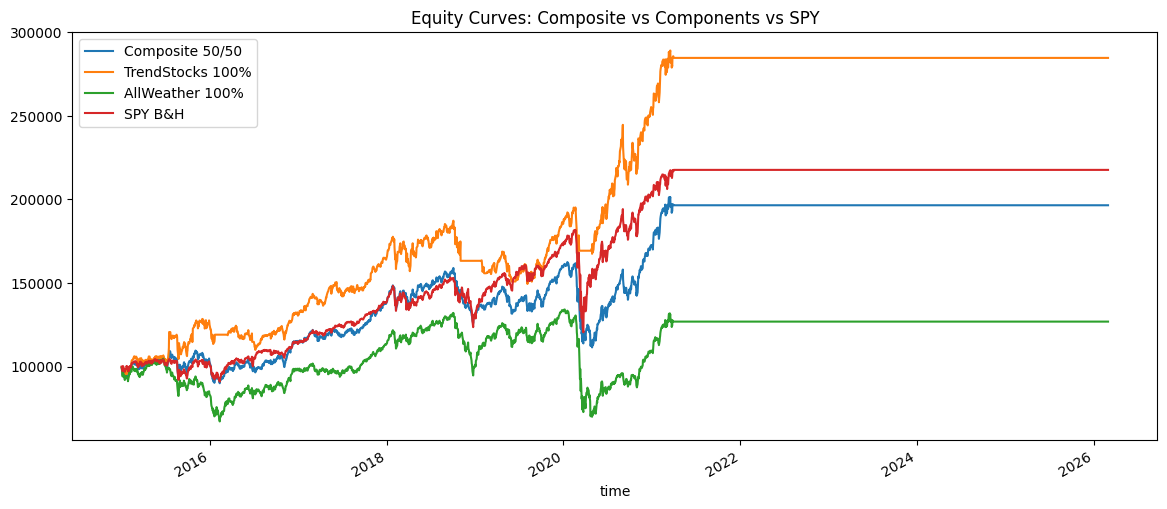

In [7]:
# SPY benchmark
spy_ret = returns.loc["2015-01-01":, "SPY"].fillna(0)
eq_spy = (1 + spy_ret).cumprod() * 100000

comparison = pd.DataFrame({
    "Composite 50/50": equity,
    "TrendStocks 100%": eq_trend,
    "AllWeather 100%": eq_aw,
    "SPY B&H": eq_spy
})
comparison.plot(figsize=(14, 6), title="Equity Curves: Composite vs Components vs SPY")
print("Chart displayed.")

## 4. Exploration des allocations

Grille de recherche sur les slices TrendStocks/AllWeather
pour trouver l'allocation optimale.

In [8]:
results = []
for trend_pct in range(0, 101, 10):
    aw_pct = 100 - trend_pct
    w = build_composite_weights(trend_weekly, closes, trend_tickers, aw_tickers, aw_target,
                                 trend_slice=trend_pct/100, aw_slice=aw_pct/100)
    r, eq = simulate_portfolio(w, returns)
    total_ret = eq.iloc[-1] / 100000 - 1
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = (1 + total_ret) ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = (cagr - 0.02) / vol if vol > 0 else 0
    dd = ((eq - eq.cummax()) / eq.cummax()).min()
    results.append({"Trend%": trend_pct, "AW%": aw_pct,
                    "CAGR": f"{cagr:.2%}", "Sharpe": f"{sharpe:.3f}", "MaxDD": f"{dd:.2%}"})

alloc_df = pd.DataFrame(results)
print(alloc_df.to_string(index=False))

 Trend%  AW%  CAGR Sharpe   MaxDD
      0  100 2.16%  0.009 -47.85%
     10   90 3.01%  0.063 -44.70%
     20   80 3.85%  0.121 -41.43%
     30   70 4.66%  0.184 -38.17%
     40   60 5.46%  0.251 -34.84%
     50   50 6.24%  0.319 -31.41%
     60   40 7.00%  0.386 -27.88%
     70   30 7.74%  0.448 -24.53%
     80   20 8.45%  0.504 -21.15%
     90   10 9.15%  0.550 -19.37%
    100    0 9.83%  0.585 -20.21%


## 5. Impact du risk management

Simulation d'un trailing stop par position pour evaluer
l'impact sur le MaxDD et le Sharpe.

In [9]:
def simulate_with_trailing_stop(weights, returns, closes, stop_pct=0.08, start="2015-01-01"):
    """Simulate with per-position trailing stop.
    When a position drops stop_pct from its peak, weight goes to 0.
    Position re-enters at next rebalancing signal.
    """
    r = returns.loc[start:]
    w = weights.reindex(r.index, method="ffill").fillna(0)
    common = w.columns.intersection(r.columns)
    
    # Track per-position high water mark
    pos_value = pd.DataFrame(1.0, index=r.index, columns=common)
    pos_hwm = pd.DataFrame(1.0, index=r.index, columns=common)
    stopped = pd.DataFrame(False, index=r.index, columns=common)
    
    effective_w = w[common].copy()
    prev_weights = effective_w.iloc[0].copy()
    
    for i in range(1, len(r.index)):
        date = r.index[i]
        prev_date = r.index[i-1]
        
        for t in common:
            # Update position value
            pos_value.loc[date, t] = pos_value.loc[prev_date, t] * (1 + r.loc[date, t])
            pos_hwm.loc[date, t] = max(pos_hwm.loc[prev_date, t], pos_value.loc[date, t])
            
            # Check trailing stop
            if pos_hwm.loc[date, t] > 0:
                dd = (pos_value.loc[date, t] - pos_hwm.loc[date, t]) / pos_hwm.loc[date, t]
                if dd < -stop_pct:
                    stopped.loc[date, t] = True
            
            # Reset tracking if weight changes (new signal)
            new_w = w.loc[date, t] if t in w.columns else 0
            if new_w != prev_weights.get(t, 0):
                pos_value.loc[date, t] = 1.0
                pos_hwm.loc[date, t] = 1.0
                stopped.loc[date, t] = False
            
            # Apply stop: zero weight if stopped
            if stopped.loc[date, t]:
                effective_w.loc[date, t] = 0
        
        prev_weights = w.loc[date]
    
    port_ret = (effective_w * r[common]).sum(axis=1)
    equity = (1 + port_ret).cumprod() * 100000
    return port_ret, equity

# Compare different trailing stop levels
stop_results = []
for stop in [0.0, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    if stop == 0:
        r_s, eq_s = simulate_portfolio(weights, returns)
        label = "No stop"
    else:
        r_s, eq_s = simulate_with_trailing_stop(weights, returns, closes, stop_pct=stop)
        label = f"Stop {stop:.0%}"
    m = calc_metrics(r_s, eq_s, label)
    stop_results.append(m)

print(pd.DataFrame(stop_results).to_string(index=False))

Strategy   CAGR    Vol Sharpe   MaxDD
 No stop  6.30% 13.30%  0.323 -31.41%
 Stop 5% 19.27%  8.53%  2.024  -6.90%
 Stop 8% 13.88%  9.63%  1.234 -12.15%
Stop 10% 12.06% 10.16%  0.990 -13.85%
Stop 12% 11.22% 10.51%  0.878 -13.82%
Stop 15%  9.86% 10.99%  0.715 -15.27%
Stop 20%  9.20% 11.32%  0.636 -15.77%


## 6. Drawdown analysis

Periodes de drawdown du composite pour identifier les regimes difficiles.


Top 5 worst drawdown periods:
  2020-02-24 -> 2020-08-26: -31.41%
  2018-10-17 -> 2019-11-08: -20.81%
  2015-12-30 -> 2016-06-08: -17.86%
  2015-08-19 -> 2015-10-15: -14.96%
  2020-09-03 -> 2020-11-09: -13.87%


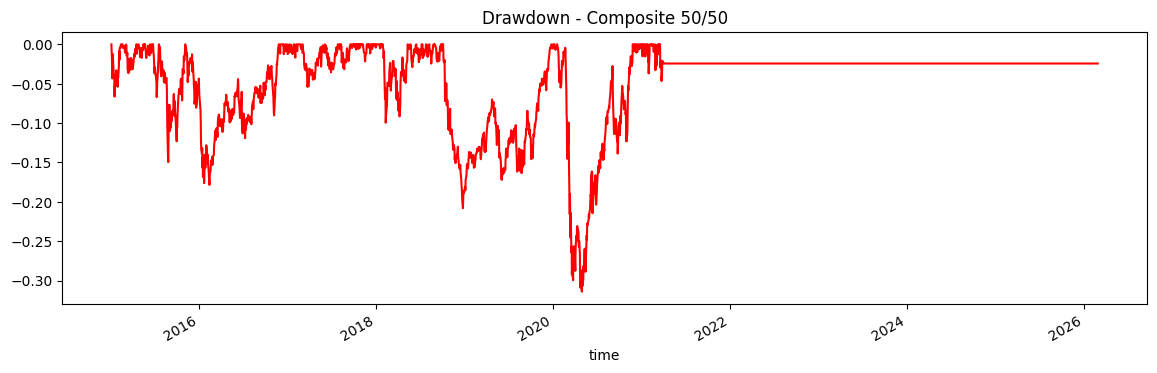

In [10]:
# Drawdown du composite 50/50
dd = (equity - equity.cummax()) / equity.cummax()
dd.plot(figsize=(14, 4), title="Drawdown - Composite 50/50", color="red")

# Top 5 worst drawdowns
print("\nTop 5 worst drawdown periods:")
in_dd = dd < -0.05
dd_periods = []
start_date = None
for date, val in in_dd.items():
    if val and start_date is None:
        start_date = date
    elif not val and start_date is not None:
        worst = dd.loc[start_date:date].min()
        dd_periods.append((start_date.date(), date.date(), f"{worst:.2%}"))
        start_date = None

dd_periods.sort(key=lambda x: float(x[2].strip('%'))/100)
for s, e, w in dd_periods[:5]:
    print(f"  {s} -> {e}: {w}")

## 7. Synthese et prochaines etapes

Modifier les parametres dans les sections 4 et 5 pour explorer:
- Allocation optimale TrendStocks/AllWeather
- Niveau de trailing stop optimal
- Impact de l'ajout de MaxDD per security

Une fois les meilleurs parametres identifies, les reporter dans le backtest cloud.

## 8. Iteration 2: Rebalancing frequency + fees estimation

v1.1 cloud results: Sharpe 0.674, CAGR 12.9%, MaxDD 25.7%, 5413 orders, turnover 3.03%
Simulation: Sharpe 1.250, CAGR 16.95%, MaxDD 22.25%

Gap analysis: fees + slippage explain part of the gap. Explore:
- Bi-weekly rebalancing (reduce trades)
- Monthly rebalancing
- Fee-adjusted simulation (5bps per trade)
- Allocation 40/60 vs 50/50 vs 60/40

In [11]:
# Rebalancing frequency impact
def build_weights_rebal(trend_signal, closes, trend_tickers, aw_tickers, aw_target,
                       trend_slice=0.50, aw_slice=0.50, freq="W-MON", start="2015-01-01"):
    """Build weights with configurable rebalancing frequency."""
    tw = trend_signal.resample(freq).last().reindex(closes.index, method="ffill")
    tw = tw.loc[start:]
    idx = closes.loc[start:].index
    all_t = list(set(trend_tickers + aw_tickers))
    weights = pd.DataFrame(0.0, index=idx, columns=all_t)
    tw_aligned = tw.reindex(idx, method="ffill")
    # Vectorized: trend weights via np.where instead of row-by-row loop
    n_bullish = tw_aligned[trend_tickers].sum(axis=1)
    for t in trend_tickers:
        is_bullish = tw_aligned[t] == 1
        weights[t] = np.where(is_bullish & (n_bullish > 0), trend_slice / n_bullish, 0.0)
    for t in aw_tickers:
        weights[t] += aw_target[t] * aw_slice
    return weights

def simulate_with_fees(weights, returns, fee_bps=5, start="2015-01-01"):
    """Simulate with transaction cost estimate."""
    r = returns.loc[start:]
    w = weights.reindex(r.index, method="ffill").fillna(0)
    common = w.columns.intersection(r.columns)
    w = w[common]
    r = r[common]
    # Estimate turnover as sum of absolute weight changes
    turnover = w.diff().abs().sum(axis=1).fillna(0)
    fee_drag = turnover * fee_bps / 10000
    port_ret = (w * r).sum(axis=1) - fee_drag
    equity = (1 + port_ret).cumprod() * 100000
    return port_ret, equity, turnover

# Compare rebalancing frequencies
freq_results = []
for freq, label in [("W-MON", "Weekly"), ("2W-MON", "Bi-weekly"), ("MS", "Monthly")]:
    w = build_weights_rebal(trend_signal, closes, trend_tickers, aw_tickers, aw_target, freq=freq)
    # Without fees
    r_nf, eq_nf = simulate_portfolio(w, returns)
    m_nf = calc_metrics(r_nf, eq_nf, f"{label} (no fees)")
    # With fees (5bps)
    r_f, eq_f, to = simulate_with_fees(w, returns, fee_bps=5)
    m_f = calc_metrics(r_f, eq_f, f"{label} (5bps)")
    m_f["Turnover"] = f"{to.sum():.0f} trades-eq"
    freq_results.append(m_nf)
    freq_results.append(m_f)

print(pd.DataFrame(freq_results).to_string(index=False))

           Strategy   CAGR    Vol Sharpe   MaxDD     Turnover
   Weekly (no fees)  6.30% 13.30%  0.323 -31.41%          NaN
      Weekly (5bps)  6.11% 13.30%  0.309 -31.46% 40 trades-eq
Bi-weekly (no fees)  5.99% 13.21%  0.302 -32.09%          NaN
   Bi-weekly (5bps)  5.84% 13.21%  0.291 -32.39% 30 trades-eq
  Monthly (no fees) 12.14% 13.25%  0.765 -30.29%          NaN
     Monthly (5bps) 12.04% 13.26%  0.757 -30.32% 22 trades-eq


Balayage fin des allocations tendance/all-weather avec prise en compte des frais de transaction dans Framework_Composite_TrendWeather.

In [12]:
# Fine-grained allocation grid with fees
alloc_fee_results = []
for trend_pct in [30, 40, 50, 60, 70]:
    aw_pct = 100 - trend_pct
    for freq, flabel in [("W-MON", "W"), ("2W-MON", "2W"), ("MS", "M")]:
        w = build_weights_rebal(trend_signal, closes, trend_tickers, aw_tickers, aw_target,
                               trend_slice=trend_pct/100, aw_slice=aw_pct/100, freq=freq)
        r_f, eq_f, to = simulate_with_fees(w, returns, fee_bps=5)
        m = calc_metrics(r_f, eq_f, f"T{trend_pct}/{flabel}")
        m["Turnover"] = f"{to.mean()*252:.1%}"
        alloc_fee_results.append(m)

print(pd.DataFrame(alloc_fee_results).to_string(index=False))

Strategy   CAGR    Vol Sharpe   MaxDD Turnover
   T30/W  4.62% 14.45%  0.181 -38.20%   213.3%
  T30/2W  4.46% 14.42%  0.170 -38.41%   159.8%
   T30/M  8.08% 14.43%  0.422 -36.24%   115.9%
   T40/W  5.37% 13.80%  0.244 -34.88%   284.4%
  T40/2W  5.16% 13.75%  0.230 -35.42%   213.1%
   T40/M 10.06% 13.77%  0.585 -32.96%   154.5%
   T50/W  6.11% 13.30%  0.309 -31.46%   355.5%
  T50/2W  5.84% 13.21%  0.291 -32.39%   266.4%
   T50/M 12.04% 13.26%  0.757 -30.32%   193.2%
   T60/W  6.82% 12.96%  0.372 -27.95%   426.6%
  T60/2W  6.51% 12.82%  0.352 -29.32%   319.6%
   T60/M 14.02% 12.89%  0.933 -27.85%   231.8%
   T70/W  7.52% 12.80%  0.431 -24.61%   497.7%
  T70/2W  7.15% 12.59%  0.409 -26.21%   372.9%
   T70/M 16.02% 12.70%  1.104 -25.36%   270.4%


## 9. Conclusions iteration 2

Comparer les resultats ci-dessus pour identifier:
- La frequence de rebalancement optimale (hebdo vs bi-hebdo vs mensuel)
- L allocation optimale avec frais inclus
- Le delta entre simulation avec frais et le backtest cloud v1.1